In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("insurance.csv") # df = dataframe. Ask python to access this dataset to be worked on.
df.head(10) ## Let python display the first 10 rows, including its columns for you to verify the right dataset has been uploaded.

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [6]:
df.info() # Structural description of my data including data types, column names, and non-null counts. Tells you if there are places where null entries exist or not as well.
df.describe() # Statistical description of my dataset including how many data is in the set. Also tells mean, max/min, percentiles, and the like.

df = pd.get_dummies(df, drop_first=True) # Converts categorical variables to numerical variables for easy reading while through one-hot encoding while aviding multicollinearity.
df.head(10) # Display the firt 10 columns of the dataset to show if we are right on track.

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False
5,31,25.740,0,3756.62160,False,False,False,True,False
6,46,33.440,1,8240.58960,False,False,False,True,False
7,37,27.740,3,7281.50560,False,False,True,False,False
8,37,29.830,2,6406.41070,True,False,False,False,False
9,60,25.840,0,28923.13692,False,False,True,False,False


In [7]:
from sklearn.model_selection import train_test_split   # We are going to start our model training by importing the traintestsplit function form ur modelselection model of scikitlearn library

X = df.drop(columns ="charges") #I want to drop the charges column from my training as that is my target and I don't need it in training. All other inputs remain.
y = df["charges"] #Index the target (charges) to y. Or attribute it to y.

bool_columns = X.select_dtypes(include="bool").columns # In a variable called bool_columns, I want to identify and assign all columns that contain booleans by name. include = "bool" says include only columns that contain booleans. ".column" retuns names of columns that contain booleans
X[bool_columns] = X[bool_columns].astype(int) # Convert all bools in bool categories in bool_columns into integers so math can be performed on them

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)  #We split both X and y into training and testing sets. test_size = 0.2 to indicate that 205 of data in testing and 85 in training. Also control randomness of results by introducing the randomness factor (random_state = 42).

print("X_train shape:", X_train.shape) # Use the .shape attribute to tell the size or dimensions of your object. That is number of rows and columns. Because we want to confirm if our 20/80 split was right and that our code is working as desired.
print("X_test shape:", X_test.shape)



from sklearn.linear_model import LinearRegression #Import the LinearRegression class, which will be the blueprint for creating ou LinearRegression model as we cannt create the model without the blueprint

model = LinearRegression() # Let's then create a variable called model that will store our intance or object, LinearRegression(). This will help us prep for our linearregression model we want to create.
model.fit(X_train, y_train) # We finally train our model using the train dataset. We have to use the .fit() method as it represemts finding the mathematical relationships between inputs and outputs.

print("Model trained successfully")

X_train shape: (1070, 8)
X_test shape: (268, 8)
Model trained successfully


Mean Absolute Error: 4181.194473753649
Mean Squared Error: 33596915.85136145
R-squared: 0.7835929767120724


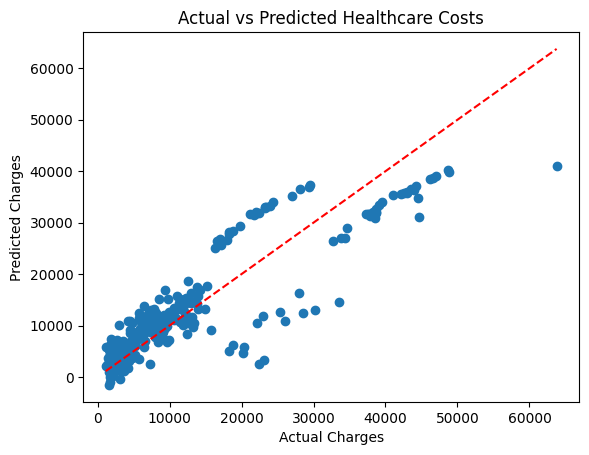

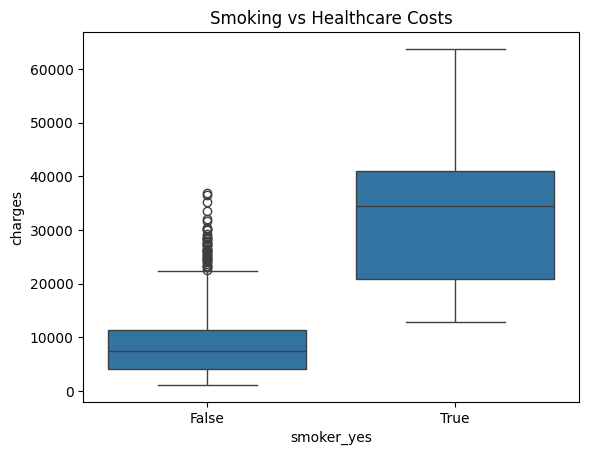

In [10]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test) #We now want to use our LinearRegression model to make predictions. Remember the LinearRegression class provides access to the fit and predict methods
predictions[:5] #We will show first 5 predictions using slicing

df = pd.read_csv("insurance.csv")
df = pd.get_dummies(df, drop_first=True)

X = df.drop("charges", axis=1)
y = df["charges"]

bool_columns = X.select_dtypes(include="bool").columns
X[bool_columns] = X[bool_columns].astype(int)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score #Sklearn.metrics contains tools for evaluating the performance of our model so we will use that now. We will import the functions, mae, mse, and r2 from here and evaluate our model with these.

print("Mean Absolute Error:", mean_absolute_error(y_test, predictions)) # We will then calculate and print the mae
print("Mean Squared Error:", mean_squared_error(y_test, predictions)) # We will then calculate and print the print mse
print("R-squared:", r2_score(y_test, predictions)) # We will then calculate and print the print r2 (how much of a variation in the target variable which is charges is explained by our model)


import matplotlib.pyplot as plt # We will then import our pyplot module from matplotlib and name it as plt so we cab do some visualizations as well.

plt.scatter(y_test, predictions) # We will plot a scatter graph of actual vs predicted values using the .scatter function.
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],linestyle='--', color = 'red')
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Healthcare Costs")
plt.savefig("prediction_plot1.png") #We save the figure for hosting on github.
plt.show()


coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(by="Coefficient", ascending=False)


sns.boxplot(x="smoker_yes", y="charges", data=df)
plt.title("Smoking vs Healthcare Costs")

plt.savefig("prediction_plot2.png")
plt.show()


